# ProteinLens Notebook

This notebook mirrors the deterministic analysis used in the app so the workflow stays understandable and beginner-friendly.

## Biological Question

What basic information can we learn from a protein sequence using Python before moving to more advanced database or structure analysis?

In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.plots import create_composition_chart
from src.protein_analysis import (
    build_summary_table,
    build_top_amino_acid_table,
    generate_protein_profile,
    summarize_protein_sequence,
)


## Input Sequence

We start with the example FASTA file stored in the `data/` folder.

In [4]:
example_text = (PROJECT_ROOT / 'data' / 'example_protein.fasta').read_text()
print(example_text)


>Example_Protein
MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVIDGETCLLDILDTAG
QEEYSAMRDQYMRTGEGFLCVFAINNTKSFEDIHQYREQIKRVKDSDDVPMVLVGNKCDL
AARTVESRQAQDLARSYGIPYIETSAKTRQGVDDAFYTLVREIRQHKLRKLNPPDESGPG
CMSCKCVLS




## Deterministic Analysis

The next step parses the sequence, cleans it, validates it, and calculates summary metrics.

In [5]:
summary = summarize_protein_sequence(example_text)
summary


{'input_type': 'FASTA',
 'cleaned_sequence': 'MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVIDGETCLLDILDTAGQEEYSAMRDQYMRTGEGFLCVFAINNTKSFEDIHQYREQIKRVKDSDDVPMVLVGNKCDLAARTVESRQAQDLARSYGIPYIETSAKTRQGVDDAFYTLVREIRQHKLRKLNPPDESGPGCMSCKCVLS',
 'wrapped_sequence': 'MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVIDGETCLLDILDTAG\nQEEYSAMRDQYMRTGEGFLCVFAINNTKSFEDIHQYREQIKRVKDSDDVPMVLVGNKCDL\nAARTVESRQAQDLARSYGIPYIETSAKTRQGVDDAFYTLVREIRQHKLRKLNPPDESGPG\nCMSCKCVLS',
 'sequence_length': 189,
 'unique_amino_acids_detected': 19,
 'most_common_amino_acid': 'D',
 'amino_acid_composition': [{'amino_acid': 'A',
   'count': 11,
   'percentage': 5.82},
  {'amino_acid': 'C', 'count': 6, 'percentage': 3.17},
  {'amino_acid': 'D', 'count': 16, 'percentage': 8.47},
  {'amino_acid': 'E', 'count': 13, 'percentage': 6.88},
  {'amino_acid': 'F', 'count': 5, 'percentage': 2.65},
  {'amino_acid': 'G', 'count': 13, 'percentage': 6.88},
  {'amino_acid': 'H', 'count': 3, 'percentage': 1.59},
  {'amino_acid': 'I', 'count

In [6]:
build_summary_table(summary)


[['Input type', 'FASTA'],
 ['Sequence length', 189],
 ['Unique amino acids detected', 19],
 ['Most common amino acid', 'D']]

In [7]:
build_top_amino_acid_table(summary)


[['D', 16, 8.47],
 ['V', 16, 8.47],
 ['L', 14, 7.41],
 ['E', 13, 6.88],
 ['G', 13, 6.88]]

## Visualization

This chart shows the percentage composition for each detected amino acid.

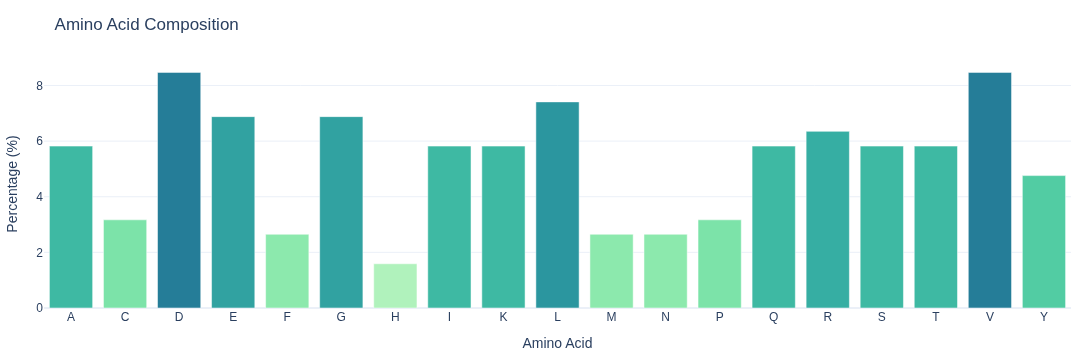

In [8]:
create_composition_chart(summary['amino_acid_composition'])


## Cautious Interpretation Template

This interpretation is deterministic and intentionally conservative. It is not a substitute for database verification or literature review.

In [9]:
print(generate_protein_profile(summary, protein_name='Example Protein'))


## Plain-English Summary

Example Protein has a sequence length of 189 amino acids. The most common detected amino acid is D, and the sequence contains 19 unique amino acid types.

## Key Observations

- Input type: FASTA
- Most enriched residues in this simple composition view: D (8.47%), V (8.47%), L (7.41%)
- This summary reflects sequence composition only, not confirmed structure or function

## Possible Biological Interpretation

Amino acid composition can help describe a protein at a basic level, but composition alone is not enough to identify function, enzyme activity, localization, or drug relevance.

## Limitations

- No database lookup was used
- No domain, motif, or structure analysis was performed
- No experimental evidence is included

## What to Verify Manually

- Confirm the protein identity with UniProt or a similar database
- Check whether known domains or motifs match the sequence
- Review literature before making biological or drug-target claims



## Limitations

- This is a composition-based summary only.
- No domain analysis, database lookup, or structure prediction is included.
- Biological interpretation must be verified manually.

## Optional Extension: Compare Two Sequences

The app now supports comparing two sequences. The example below shows how to run the same logic directly in Python.

In [ ]:
from src.protein_analysis import compare_protein_sequences

comparison = compare_protein_sequences(example_text, example_text, 'Example A', 'Example B')
comparison['notes']
